### Questão 1

**Enunciado:** O gerente de uma linha de montagem deseja prever a quantidade de peças produzidas com base apenas nas horas de operação de uma máquina específica, visando planejar as metas da próxima semana. Escolha o algoritmo para prever o volume de produção. No seu notebook, apresente a linha de tendência sobre os dados e calcule o coeficiente de correlação para validar a força da relação.

**Problema:** Prever a quantidade de peças produzidas com base nas horas de operação de uma máquina.

**Algoritmo Apropriado:** ``Regressão Linear Simples``.

**Justificativa:** O problema consiste em prever um valor contínuo (peças produzidas) com base em apenas uma variável independente (horas de operação). O objetivo da regressão linear simples é estabelecer essa relação através de uma linha reta que melhor se ajusta aos dados.

#### **Importando as bibliotecas**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#### **Carregamento do Dataset**

In [3]:
try:
    # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows=1
    dados = np.loadtxt('datasets/dataset_q1.csv', delimiter=',', skiprows=1)

    X = dados[:, 0]
    y = dados[:, 1]

    # Visualiza os dados
    print("X:", X)
    print("y:", y)

    print("\n Número de amostras:", X.shape[0])

except FileNotFoundError:
    print("Erro: Arquivo do dataset não encontrado.")
    exit()

X: [ 1.   2.5  3.   4.5  5.   6.5  7.   8.   9.5 10.  11.5 12.  13.5 14.
 15. ]
y: [ 12.  28.  35.  50.  58.  72.  80.  92. 108. 115. 130. 138. 152. 160.
 175.]

 Número de amostras: 15


#### **Calculando os coeficientes da regressão linear (a e b)**

In [ ]:
x_mean = np.mean(X)
y_mean = np.mean(y)

numerador = np.sum((X - x_mean) * (y - y_mean))
denominador = np.sum((X - x_mean)**2)

# m representa o 'b' na fórmula y = a + bx, intercepto b representa o 'a'
m = numerador / denominador
b = y_mean - (m * x_mean)

print(f"Coeficiente angular (m/b): {m:.4f}")
print(f"Intercepto (b/a): {b:.4f}")
print("\nEquação da linha: y = {:.4f}x + {:.4f}".format(m, b))

Coeficiente angular (m/b): 11.4754
Intercepto (b/a): -0.4312

Equação da linha: y = 11.4754x + -0.4312


#### **Fazer as previsões do modelo e calcular correlação**

In [ ]:
y_pred = m * X + b

# Calcular o R-quadrado (R²)
sqr = np.sum((y - y_pred)**2) # Soma Quadrática dos Resíduos
sqt = np.sum((y - y_mean)**2) # Soma Quadrática Total
r2 = 1 - (sqr / sqt)

# Coeficiente de Correlação de Pearson (r)
r = np.sqrt(r2) if m > 0 else -np.sqrt(r2)

print(f"Coeficiente de Correlação (r): {r:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

Coeficiente de Correlação (r): 0.9996
Coeficiente de Determinação (R²): 0.9992


#### **Criar a linha de regressão para visualização**

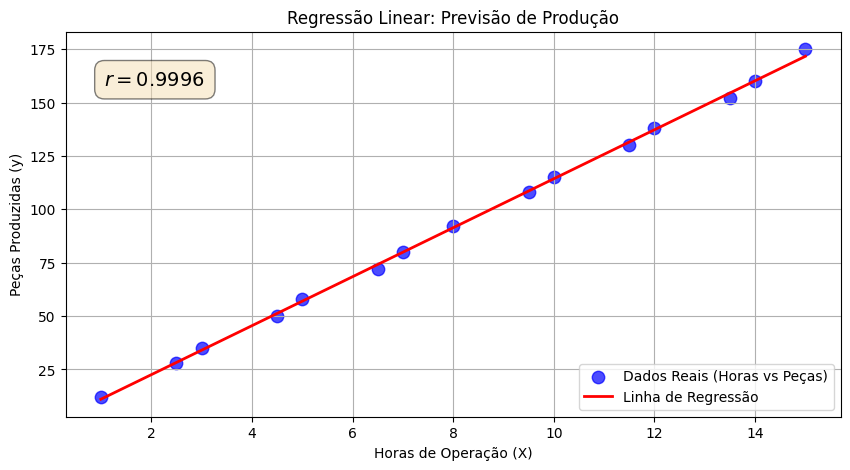

In [ ]:
X_line = np.array([X.min(), X.max()])
y_line = m * X_line + b

# 5. Visualizar os resultados em um gráfico
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label='Dados Reais (Horas vs Peças)', alpha=0.7, color='blue', s=80)
plt.plot(X_line, y_line, color='red', linewidth=2, label='Linha de Regressão')

plt.text(0.05, 0.9, f'$r = {r:.4f}$', transform=plt.gca().transAxes, 
         fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.title('Regressão Linear: Previsão de Produção')
plt.xlabel('Horas de Operação (X)')
plt.ylabel('Peças Produzidas (y)')
plt.legend()
plt.grid(True)
plt.show()

### **Interpretação dos Resultados**
O modelo ajustou a linha reta minimizando os erros em relação aos pontos reais. O coeficiente de correlação ($r$) calculado revela a força e a direção dessa relação. Um valor de $r$ próximo de 1 indica uma forte correlação positiva, o que significa que conforme as horas de operação da máquina aumentam, o volume de peças produzidas também aumenta de forma linear e altamente previsível.